In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
print(X_train.shape)
print(X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1318s 8us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [4]:
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

classes = ["airplane","automobile","bird","cat","deer",
           "dog","frog","horse","ship","truck"]

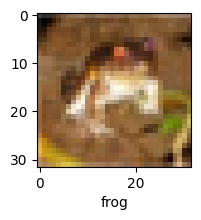

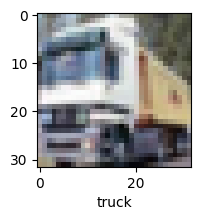

In [5]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

plot_sample(X_train, y_train, 0)
plot_sample(X_train, y_train, 1)

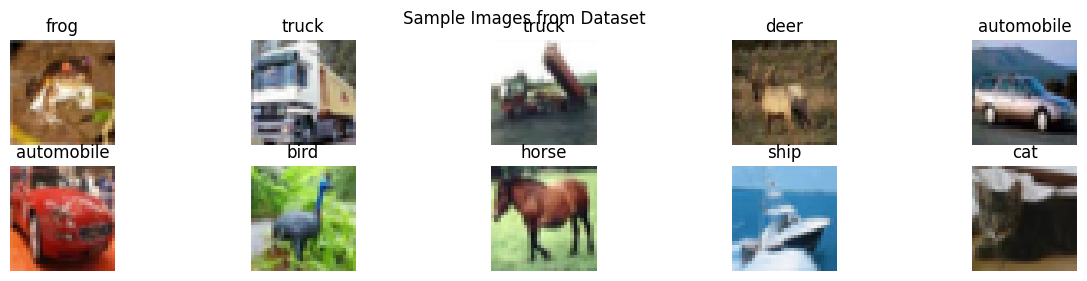

In [6]:
# Show 10 sample images in one figure
plt.figure(figsize=(15,3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(classes[y_train[i]])
    plt.axis('off')
plt.suptitle('Sample Images from Dataset')
plt.show()

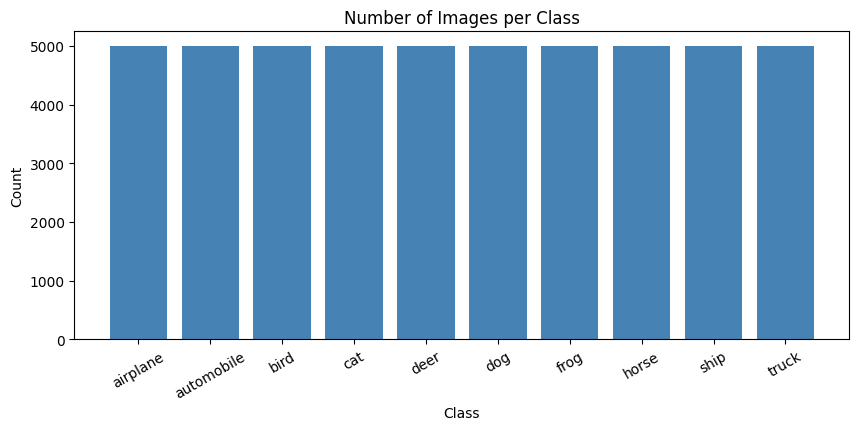

In [7]:
# Count images in each class
counts = []
for i in range(10):
    count = len(y_train[y_train == i])
    counts.append(count)

# Plot class distribution
plt.figure(figsize=(10,4))
plt.bar(classes, counts, color='steelblue')
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:
ann = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann.compile(optimizer='SGD',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 147s 94ms/step - accuracy: 0.3572 - loss: 1.8114
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 207s 97ms/step - accuracy: 0.4273 - loss: 1.6214
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 208s 101ms/step - accuracy: 0.4551 - loss: 1.5403
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 179s 86ms/step - accuracy: 0.4768 - loss: 1.4820
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 87ms/step - accuracy: 0.4966 - loss: 1.4304


In [10]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report ANN:")
print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step
Classification Report ANN:
              precision    recall  f1-score   support

           0       0.56      0.54      0.55      1000
           1       0.47      0.76      0.58      1000
           2       0.38      0.34      0.36      1000
           3       0.35      0.31      0.33      1000
           4       0.38      0.51      0.44      1000
           5       0.38      0.42      0.40      1000
           6       0.54      0.52      0.53      1000
           7       0.73      0.36      0.48      1000
           8       0.54      0.68      0.61      1000
           9       0.64      0.31      0.42      1000

    accuracy                           0.48     10000
   macro avg       0.50      0.48      0.47     10000
weighted avg       0.50      0.48      0.47     10000



In [11]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3),
                  activation='relu',
                  input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=64, kernel_size=(3,3),
                  activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.fit(X_train, y_train, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.4796 - loss: 1.4403
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.6102 - loss: 1.1087
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6549 - loss: 0.9867
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6834 - loss: 0.9098
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 44ms/step - accuracy: 0.7053 - loss: 0.8495
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.7193 - loss: 0.8025
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.7351 - loss: 0.7580
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.7490 - loss: 0.7212
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.7642 - loss: 0.6797
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.7723 - loss: 0.6485


In [12]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6930 - loss: 0.9376


[0.9376027584075928, 0.6930000185966492]

In [13]:
y_pred = cnn.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report CNN:")
print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
Classification Report CNN:
              precision    recall  f1-score   support

           0       0.77      0.65      0.71      1000
           1       0.84      0.80      0.82      1000
           2       0.58      0.61      0.60      1000
           3       0.63      0.34      0.44      1000
           4       0.63      0.64      0.64      1000
           5       0.54      0.69      0.60      1000
           6       0.69      0.84      0.76      1000
           7       0.84      0.68      0.75      1000
           8       0.73      0.86      0.79      1000
           9       0.73      0.82      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



airplane


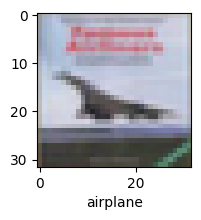

In [14]:
plot_sample(X_test, y_test, 3)
print(classes[y_pred_classes[3]])

ANN Accuracy: 0.47600001096725464
CNN Accuracy: 0.6930000185966492


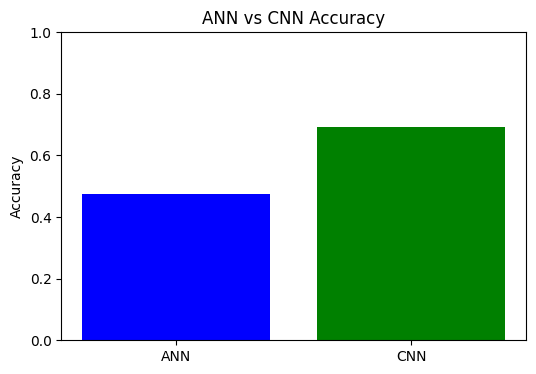

In [15]:
# Compare ANN and CNN accuracy
ann_acc = ann.evaluate(X_test, y_test, verbose=0)[1]
cnn_acc = cnn.evaluate(X_test, y_test, verbose=0)[1]

print("ANN Accuracy:", ann_acc)
print("CNN Accuracy:", cnn_acc)

# Simple bar chart
plt.figure(figsize=(6,4))
plt.bar(['ANN','CNN'],
        [ann_acc, cnn_acc],
        color=['blue','green'])
plt.title('ANN vs CNN Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

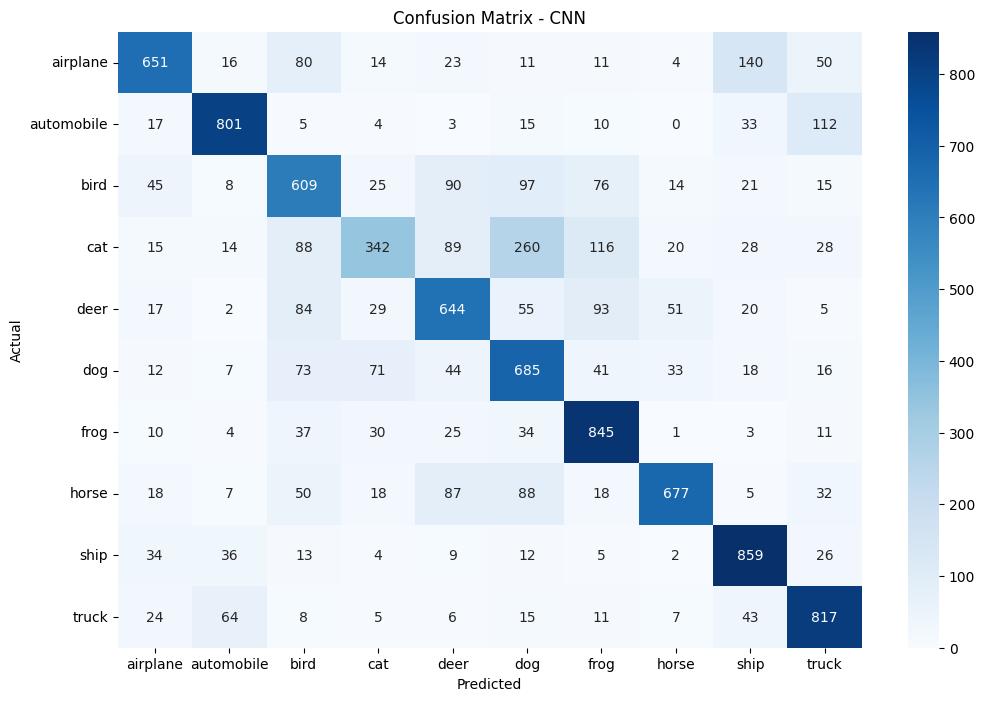

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion matrix for CNN
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(12,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.title('Confusion Matrix - CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()